# 06. Explainability

Step 8에서 고정한 **RandomForest balanced + Subset D (91개)** 와 train OOF threshold 정책을 그대로 재현한다. Test set은 이미 최종 평가에 사용되었으므로 이 노트북에서는 모델 선택·threshold 변경·성능 최적화 없이, 고정 모델의 사후 설명과 오류 분석에만 사용한다.

익명화된 `Attribute` 번호를 실제 공정 물리량으로 해석하지 않는다.

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f'Project root could not be resolved from {cwd}')
os.environ['MPLCONFIGDIR'] = str(PROJECT_ROOT / '.cache' / 'matplotlib')
sys.path.insert(0, str(PROJECT_ROOT))

import json
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from src.load_data import load_secom_dataset, split_secom_data

REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
MISSING_THRESHOLD = 0.40
sns.set_theme(style='whitegrid')
print('SHAP version:', importlib.metadata.version('shap'))

SHAP version: 0.52.0


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Step 8 재현

동일한 stratified split 뒤 outer train에서만 constant 제거, 결측률 40% 초과 제거, median 산출을 수행한다. Subset C/D 이름 목록과 threshold는 Step 7·8 report를 그대로 읽는다.

In [2]:
modeling_summary = json.loads((REPORTS_DIR / 'modeling_summary.json').read_text(encoding='utf-8'))
feature_subsets = json.loads((REPORTS_DIR / 'feature_subsets.json').read_text(encoding='utf-8'))
assert modeling_summary['selected_model'] == 'RandomForest_balanced'
assert modeling_summary['selected_subset'] == 'D_correlation_plus_model_based'
selected_threshold = float(modeling_summary['selected_threshold'])

dataset = load_secom_dataset()
X_raw, y_frame = split_secom_data(dataset)
X_numeric = X_raw.drop(columns='timestamp').copy()
y_original = y_frame['class'].copy()
y = y_original.map({-1: 0, 1: 1}).astype(int)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
constant_features = X_train_raw.columns[X_train_raw.nunique(dropna=True) <= 1].tolist()
after_constant = [c for c in X_train_raw.columns if c not in constant_features]
train_missing_rate = X_train_raw[after_constant].isna().mean()
high_missing_features = train_missing_rate[train_missing_rate > MISSING_THRESHOLD].index.tolist()
preprocessed_features = [c for c in after_constant if c not in high_missing_features]
train_medians = X_train_raw[preprocessed_features].median()
X_train = X_train_raw[preprocessed_features].fillna(train_medians)
X_test = X_test_raw[preprocessed_features].fillna(train_medians)
subset_d = feature_subsets['D_correlation_plus_model_based']
subset_c = feature_subsets['C_correlation_plus_univariate']

assert (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum())) == (1253, 314, 83, 21)
assert len(subset_d) == 91 and len(subset_c) == 69
assert np.isclose(selected_threshold, 0.05333333333333334)
print(f'Train/Test={len(X_train)}/{len(X_test)}, Fail={int(y_train.sum())}/{int(y_test.sum())}')
print(f'Subset D={len(subset_d)}, Subset C={len(subset_c)}, threshold={selected_threshold:.12f}')

Train/Test=1253/314, Fail=83/21
Subset D=91, Subset C=69, threshold=0.053333333333


## 2. 고정 RandomForest 재학습과 예측 그룹

Step 8과 동일한 estimator를 전체 train에 재학습한다. 선택 threshold로 Test를 TP/TN/FP/FN으로 분류하되 결과를 이용해 모델이나 threshold를 바꾸지 않는다.

In [3]:
final_rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced_subsample', random_state=RANDOM_STATE,
    n_jobs=-1, max_features='sqrt'
)
final_rf.fit(X_train[subset_d], y_train)
test_probability = final_rf.predict_proba(X_test[subset_d])[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

def outcome_group(actual, predicted):
    return np.select(
        [(actual == 1) & (predicted == 1), (actual == 0) & (predicted == 0),
         (actual == 0) & (predicted == 1), (actual == 1) & (predicted == 0)],
        ['TP', 'TN', 'FP', 'FN'], default='unknown'
    )

prediction_analysis = pd.DataFrame({
    'sample_index': X_test.index,
    'actual_class': y_test.to_numpy(),
    'predicted_class': test_prediction,
    'fail_probability': test_probability,
    'threshold': selected_threshold,
    'group': outcome_group(y_test.to_numpy(), test_prediction),
})
assert prediction_analysis['group'].value_counts().to_dict() == {'TN': 176, 'FP': 117, 'TP': 18, 'FN': 3}
display(prediction_analysis.groupby('group')['fail_probability'].agg(['count', 'min', 'median', 'mean', 'max']))

,count,min,median,mean,max
group,,,,,
FN,3,0.026667,0.030000,0.034444,0.046667
FP,117,0.053333,0.076667,0.091738,0.253333
TN,176,0.003333,0.030000,0.028807,0.050000
TP,18,0.056667,0.105000,0.115556,0.216667


## 3. Global importance: impurity와 permutation

Impurity importance(MDI)는 tree split에서 누적된 불순도 감소량이므로 상관된 변수·연속형 변수에 편향될 수 있다. Permutation importance는 고정 Test에서 한 Feature를 섞을 때 **Average Precision**이 얼마나 감소하는지 측정한다. Test 사용은 고정 모델의 사후 해석에만 한정하며 음수 값은 유한 표본 변동 또는 해당 Feature 교란이 오히려 점수를 높였음을 뜻할 수 있다.

In [4]:
impurity_df = pd.DataFrame({
    'feature': subset_d,
    'rf_impurity_importance': final_rf.feature_importances_,
}).sort_values('rf_impurity_importance', ascending=False)

perm = permutation_importance(
    final_rf, X_test[subset_d], y_test, scoring='average_precision',
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1
)
permutation_df = pd.DataFrame({
    'feature': subset_d,
    'permutation_importance_mean': perm.importances_mean,
    'permutation_importance_std': perm.importances_std,
}).sort_values('permutation_importance_mean', ascending=False)

importance_comparison = impurity_df.merge(permutation_df, on='feature')
importance_comparison['impurity_rank'] = importance_comparison['rf_impurity_importance'].rank(ascending=False, method='min').astype(int)
importance_comparison['permutation_rank'] = importance_comparison['permutation_importance_mean'].rank(ascending=False, method='min').astype(int)
importance_comparison['rank_difference_perm_minus_impurity'] = importance_comparison['permutation_rank'] - importance_comparison['impurity_rank']
display(importance_comparison.sort_values('rf_impurity_importance').tail(15).sort_values('rf_impurity_importance', ascending=False))
display(importance_comparison.sort_values('permutation_importance_mean', ascending=False).head(15))

,feature,rf_impurity_importance,permutation_importance_mean,permutation_importance_std,impurity_rank,permutation_rank,rank_difference_perm_minus_impurity
0,Attribute 104,0.037092,-0.000481,0.017423,1,89,88
1,Attribute 60,0.034433,0.052735,0.015037,2,1,-1
2,Attribute 34,0.028748,0.011401,0.020237,3,68,65
3,Attribute 478,0.020511,0.035600,0.011967,4,2,-2
4,Attribute 32,0.018922,-0.010172,0.024287,5,91,86
5,Attribute 131,0.016965,0.004527,0.012958,6,84,78
6,Attribute 352,0.016804,-0.007315,0.015289,7,90,83
7,Attribute 320,0.016111,0.018162,0.009612,8,28,20
8,Attribute 511,0.015117,0.015429,0.007216,9,46,37
9,Attribute 22,0.014594,0.022851,0.008076,10,10,0


,feature,rf_impurity_importance,permutation_importance_mean,permutation_importance_std,impurity_rank,permutation_rank,rank_difference_perm_minus_impurity
1,Attribute 60,0.034433,0.052735,0.015037,2,1,-1
3,Attribute 478,0.020511,0.035600,0.011967,4,2,-2
46,Attribute 432,0.009911,0.029110,0.007737,47,3,-44
22,Attribute 66,0.011366,0.026932,0.004837,23,4,-19
52,Attribute 461,0.009214,0.026571,0.009395,53,5,-48
59,Attribute 469,0.008856,0.024795,0.008180,60,6,-54
11,Attribute 92,0.013170,0.024694,0.008638,12,7,-5
56,Attribute 118,0.009093,0.024015,0.007000,57,8,-49
34,Attribute 29,0.010699,0.023106,0.009003,35,9,-26
9,Attribute 22,0.014594,0.022851,0.008076,10,10,0


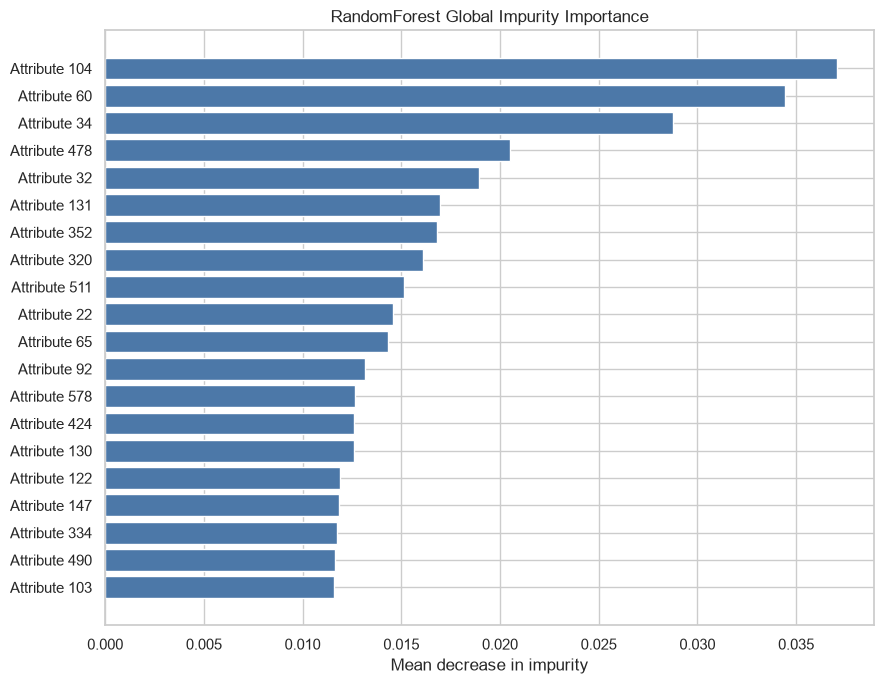

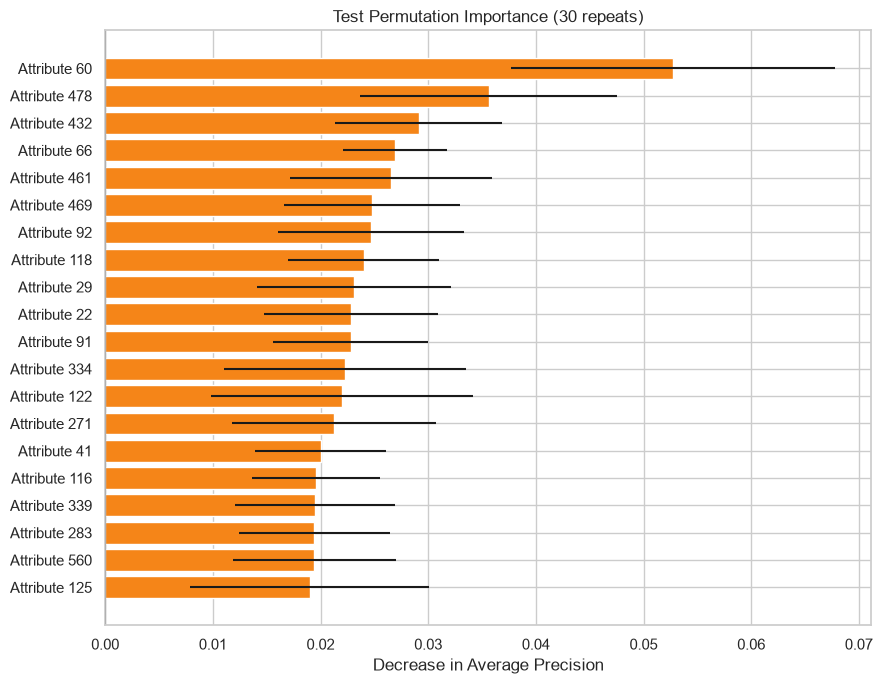

In [5]:
top_n = 20
fig, ax = plt.subplots(figsize=(9, 7))
plot_df = impurity_df.head(top_n).sort_values('rf_impurity_importance')
ax.barh(plot_df['feature'], plot_df['rf_impurity_importance'], color='#4C78A8')
ax.set(title='RandomForest Global Impurity Importance', xlabel='Mean decrease in impurity')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'explainability_rf_global_importance.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 7))
plot_df = permutation_df.head(top_n).sort_values('permutation_importance_mean')
ax.barh(plot_df['feature'], plot_df['permutation_importance_mean'], xerr=plot_df['permutation_importance_std'], color='#F58518')
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Test Permutation Importance (30 repeats)', xlabel='Decrease in Average Precision')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'explainability_permutation_importance.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. SHAP: Fail 클래스 축을 실제 shape로 확인

`TreeExplainer` 반환 shape를 출력하고, `(samples, features, classes)`이면 class index 1을 명시적으로 선택한다. 다른 지원 shape일 때만 별도 분기로 처리하며 shape를 가정하지 않는다. 아래 importance와 local explanation은 모두 **Fail(1)** 출력에 대한 값이다.

In [6]:
explainer = shap.TreeExplainer(final_rf)
shap_raw = explainer(X_test[subset_d], check_additivity=False)
print('Raw SHAP values shape:', np.shape(shap_raw.values))
print('Raw SHAP base_values shape:', np.shape(shap_raw.base_values))

if shap_raw.values.ndim == 3 and shap_raw.values.shape[2] == 2:
    fail_shap = shap.Explanation(
        values=shap_raw.values[:, :, 1],
        base_values=shap_raw.base_values[:, 1],
        data=shap_raw.data,
        feature_names=subset_d,
    )
    shap_class_handling = 'Selected class axis index 1 from (samples, features, classes) output.'
elif shap_raw.values.ndim == 2 and shap_raw.values.shape[1] == len(subset_d):
    fail_shap = shap_raw
    shap_class_handling = 'SHAP returned a 2D binary-output explanation; used it directly after shape verification.'
else:
    raise RuntimeError(f'Unsupported SHAP output shape: {np.shape(shap_raw.values)}')

mean_abs_shap = np.abs(fail_shap.values).mean(axis=0)
shap_df = pd.DataFrame({'feature': subset_d, 'mean_abs_shap_fail': mean_abs_shap}).sort_values('mean_abs_shap_fail', ascending=False)
print(shap_class_handling)
display(shap_df.head(20))

Raw SHAP values shape: (314, 91, 2)
Raw SHAP base_values shape: (314, 2)
Selected class axis index 1 from (samples, features, classes) output.


,feature,mean_abs_shap_fail
0,Attribute 104,0.021880
1,Attribute 60,0.019510
2,Attribute 34,0.015230
3,Attribute 478,0.012778
4,Attribute 32,0.011760
10,Attribute 352,0.009475
12,Attribute 320,0.008345
5,Attribute 511,0.008298
9,Attribute 22,0.008051
6,Attribute 131,0.007299


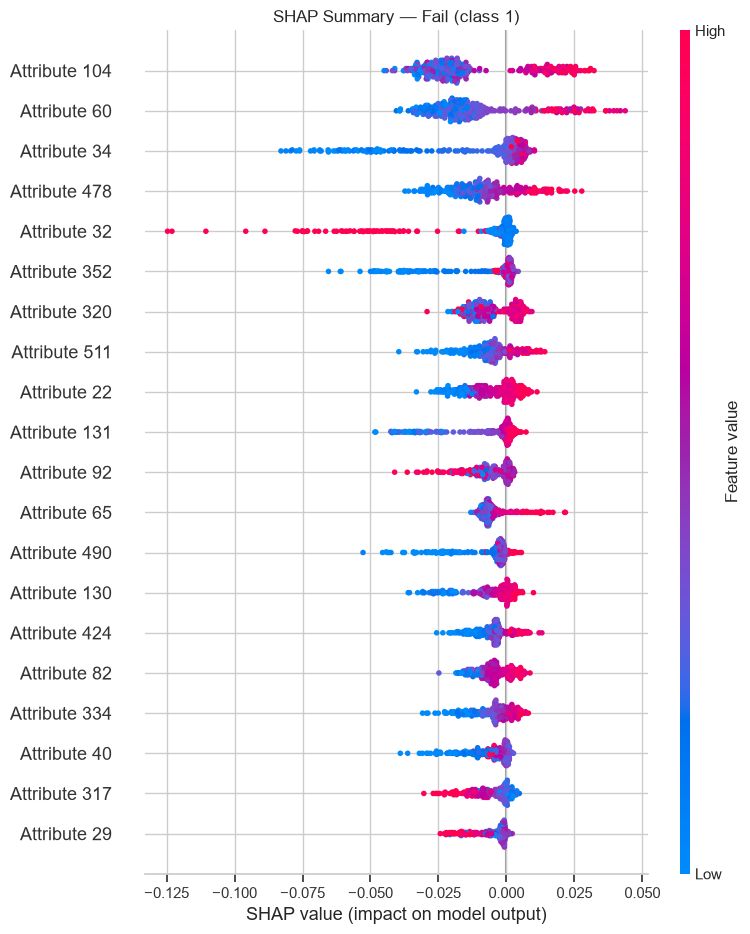

In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(fail_shap.values, X_test[subset_d], max_display=20, show=False)
plt.title('SHAP Summary — Fail (class 1)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'explainability_shap_summary_fail.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. EDA → Feature Selection → Explainability 비교

요청된 익명 Feature를 Hedges' g와 FDR, MI/RF selection, 최종 RF·permutation·SHAP importance로 연결한다. FDR 유의 기준은 Step 6의 0.05다.

In [8]:
eda_group = pd.read_csv(REPORTS_DIR / 'eda_feature_group_comparison.csv', index_col=0).rename_axis('feature').reset_index()
fs_scores = pd.read_csv(REPORTS_DIR / 'feature_selection_scores.csv', index_col=0).rename_axis('feature').reset_index()
print('EDA columns:', eda_group.columns.tolist())
print('FS columns:', fs_scores.columns.tolist())

eda_feature_col = 'feature'
fdr_col = 'fdr_bh' if 'fdr_bh' in eda_group.columns else 'fdr_adjusted_p'
tracked_features = ['Attribute 60', 'Attribute 104', 'Attribute 511', 'Attribute 349',
                    'Attribute 432', 'Attribute 431', 'Attribute 22', 'Attribute 29']

eda_keep = eda_group[[eda_feature_col, 'hedges_g', fdr_col]].rename(columns={fdr_col: 'fdr_bh'})
fs_keep_cols = [c for c in ['feature', 'mutual_information', 'univariate_selected', 'model_selected'] if c in fs_scores.columns]
feature_comparison = pd.DataFrame({'feature': tracked_features}).merge(eda_keep, on='feature', how='left').merge(fs_scores[fs_keep_cols], on='feature', how='left')
feature_comparison['fdr_significant_0_05'] = feature_comparison['fdr_bh'] < 0.05
feature_comparison['mi_selected'] = feature_comparison['feature'].isin(subset_c)
feature_comparison['rf_selected'] = feature_comparison['feature'].isin(subset_d)
feature_comparison = feature_comparison.merge(impurity_df, on='feature', how='left').merge(permutation_df, on='feature', how='left').merge(shap_df, on='feature', how='left')
feature_comparison.to_csv(REPORTS_DIR / 'explainability_feature_comparison.csv', index=False)
display(feature_comparison)

EDA columns: ['feature', 'pass_mean', 'fail_mean', 'pass_median', 'fail_median', 'pass_std', 'fail_std', 'mean_difference_fail_minus_pass', 'hedges_g', 'abs_hedges_g', 'welch_p_value', 'fdr_bh', 'fdr_significant_0_05']
FS columns: ['feature', 'train_missing_rate', 'mutual_information', 'after_correlation_pruning', 'univariate_selected', 'rf_importance', 'model_selected', 'eda_top10_effect', 'mi_rank', 'rf_rank_after_pruning']


,feature,hedges_g,fdr_bh,mutual_information,univariate_selected,model_selected,fdr_significant_0_05,mi_selected,rf_selected,rf_impurity_importance,permutation_importance_mean,permutation_importance_std,mean_abs_shap_fail
0,Attribute 60,0.633783,0.000056,0.002764,False,True,True,False,True,0.034433,0.052735,0.015037,0.019510
1,Attribute 104,0.613912,0.000089,0.020384,True,True,True,True,True,0.037092,-0.000481,0.017423,0.021880
2,Attribute 511,0.532970,0.012495,0.016341,True,True,True,True,True,0.015117,0.015429,0.007216,0.008298
3,Attribute 349,0.529447,0.134872,0.000000,False,True,False,False,True,0.008126,0.008694,0.007760,0.003087
4,Attribute 432,0.484777,0.176105,0.000000,False,True,False,False,True,0.009911,0.029110,0.007737,0.005806
5,Attribute 431,0.440483,0.247781,0.001303,False,True,False,False,True,0.007345,0.015167,0.007282,0.004136
6,Attribute 22,0.437291,0.069212,0.003807,False,True,False,False,True,0.014594,0.022851,0.008076,0.008051
7,Attribute 29,-0.431794,0.001997,0.005376,False,True,True,False,True,0.010699,0.023106,0.009003,0.006004


## 6. TP/TN/FP/FN과 낮은 threshold의 영향

확률 분포와 주요 설명 Feature의 그룹별 standardized median을 비교한다. FP가 TP와 비슷해 보이는지는 top SHAP Feature 공간에서 그룹 centroid 거리와 분포를 통해 확인한다. 이는 인과적 유사성이 아니라 모델 입력 공간에서의 기술적 유사성이다.

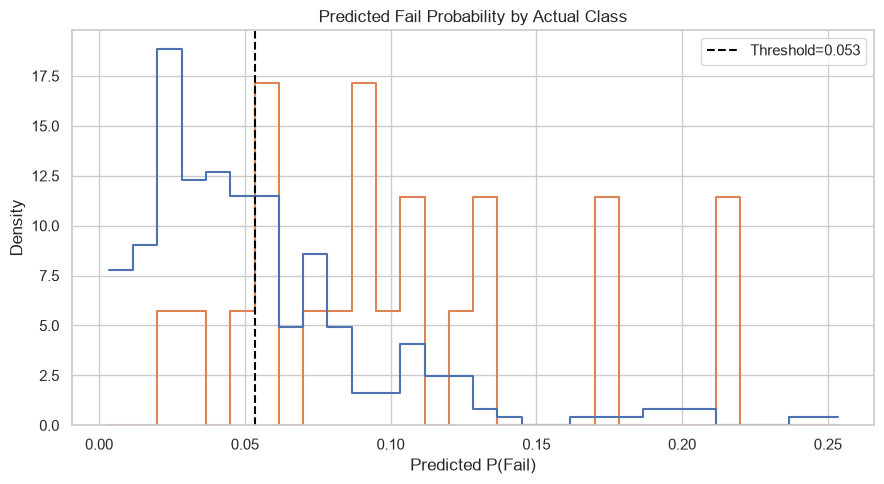

,Attribute 104,Attribute 60,Attribute 34,Attribute 478,Attribute 32,Attribute 352,Attribute 320,Attribute 511,Attribute 22,Attribute 131
group,,,,,,,,,,
FN,-0.137252,-0.122981,-0.265688,-0.179295,-0.385285,-0.819757,-0.936723,-0.257268,0.122039,0.936007
FP,0.362487,-0.197390,-0.115047,-0.127730,-0.432393,0.202844,0.515427,-0.028866,0.158184,0.417197
TN,-0.403780,-0.340831,-0.155764,-0.095097,-0.467959,-0.147687,0.025977,-0.346966,0.099646,0.047651
TP,0.229223,0.943921,-0.120583,-0.071720,-0.381812,-0.071255,0.379802,0.034587,0.235579,0.353399


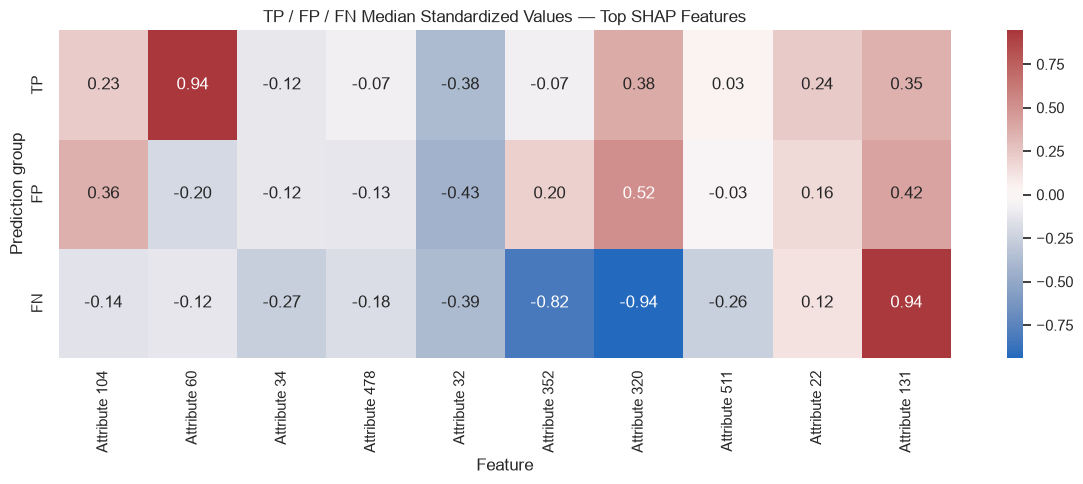

Centroid distances in top-SHAP standardized space: {'FP_to_TP': 1.1973675368584031, 'FP_to_FN': 1.9390554929517538, 'TP_to_FN': 2.00903383232977}


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
prob_df = prediction_analysis.copy()
prob_df['actual_label'] = prob_df['actual_class'].map({0: 'Pass (-1)', 1: 'Fail (1)'})
sns.histplot(data=prob_df, x='fail_probability', hue='actual_label', bins=30, stat='density', common_norm=False, element='step', fill=False, ax=ax)
ax.axvline(selected_threshold, color='black', linestyle='--', label=f'Threshold={selected_threshold:.3f}')
ax.set(title='Predicted Fail Probability by Actual Class', xlabel='Predicted P(Fail)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'explainability_probability_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

top_features = shap_df.head(10)['feature'].tolist()
train_mean = X_train[top_features].mean()
train_std = X_train[top_features].std(ddof=0).replace(0, 1)
test_z = (X_test[top_features] - train_mean) / train_std
group_feature_medians = test_z.assign(group=prediction_analysis.set_index('sample_index').loc[X_test.index, 'group'].to_numpy()).groupby('group').median()
display(group_feature_medians)

plot_groups = ['TP', 'FP', 'FN']
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(group_feature_medians.loc[plot_groups], center=0, cmap='vlag', annot=True, fmt='.2f', ax=ax)
ax.set(title='TP / FP / FN Median Standardized Values — Top SHAP Features', xlabel='Feature', ylabel='Prediction group')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'explainability_tp_fp_fn_feature_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

centroids = group_feature_medians.loc[['TP', 'FP', 'FN']]
centroid_distances = {
    'FP_to_TP': float(np.linalg.norm(centroids.loc['FP'] - centroids.loc['TP'])),
    'FP_to_FN': float(np.linalg.norm(centroids.loc['FP'] - centroids.loc['FN'])),
    'TP_to_FN': float(np.linalg.norm(centroids.loc['TP'] - centroids.loc['FN'])),
}
print('Centroid distances in top-SHAP standardized space:', centroid_distances)

## 7. 대표 local explanation과 FN 전수 점검

대표 사례는 규칙으로 고정한다: 최고 확률 TP 1개, 최고 확률 FP 1개, FN 3개 전부, threshold에 가장 가까운 borderline sample 2개. 각 사례에서 양의 SHAP은 Fail 확률 방향, 음의 SHAP은 Pass 방향 기여다.

,sample_index,group,actual_class,predicted_class,fail_probability,top_fail_direction_features,top_pass_direction_features
0,96,TP,1,1,0.216667,Attribute 104:0.030548; Attribute 60:0.026050;...,Attribute 444:-0.033390; Attribute 485:-0.0319...
1,44,FP,0,1,0.253333,Attribute 104:0.023572; Attribute 60:0.023377;...,Attribute 461:-0.036629; Attribute 132:-0.0343...
2,154,FN,1,0,0.030000,Attribute 60:0.013775; Attribute 104:0.011057;...,Attribute 32:-0.077678; Attribute 76:-0.027655...
3,1189,FN,1,0,0.046667,Attribute 82:0.004309; Attribute 15:0.003332; ...,Attribute 34:-0.065364; Attribute 352:-0.03316...
4,795,FN,1,0,0.026667,Attribute 320:0.006194; Attribute 337:0.002576...,Attribute 352:-0.038135; Attribute 490:-0.0244...
5,1036,FP,0,1,0.053333,Attribute 478:0.022419; Attribute 34:0.006918;...,Attribute 352:-0.043618; Attribute 104:-0.0277...
6,1142,FP,0,1,0.053333,Attribute 34:0.005891; Attribute 147:0.003796;...,Attribute 60:-0.031557; Attribute 104:-0.02751...


,fail_probability,Attribute 104,Attribute 60,Attribute 34,Attribute 478,Attribute 32,Attribute 352,Attribute 320,Attribute 511,Attribute 22,Attribute 131
154,0.030000,-0.0060,26.7745,8.6667,5.7668,4.7036,0.0422,4.8639,68.7631,-6362.50,0.6956
1189,0.046667,-0.0128,1.9336,8.2776,3.6107,3.4607,0.0088,5.8587,46.1388,-5447.25,0.8280
795,0.026667,-0.0102,1.5218,8.6074,4.3655,3.3762,0.0113,10.1622,37.1184,-5536.50,0.8216


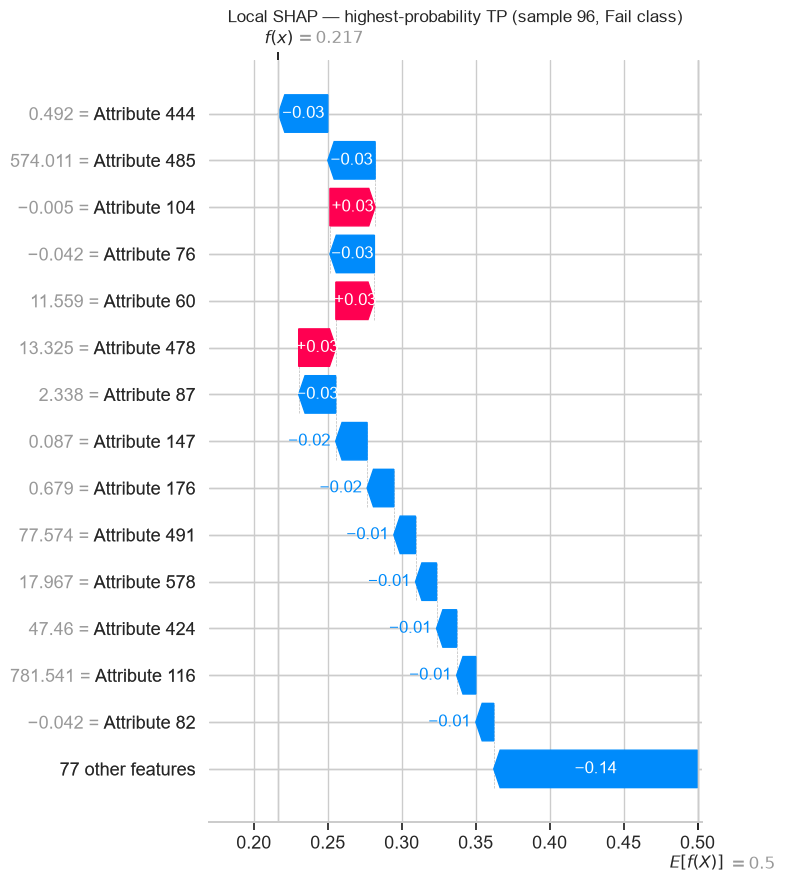

In [10]:
pa = prediction_analysis.set_index('sample_index')
tp_index = pa.query("group == 'TP'")['fail_probability'].idxmax()
fp_index = pa.query("group == 'FP'")['fail_probability'].idxmax()
fn_indices = pa.query("group == 'FN'").index.tolist()
borderline_indices = (pa['fail_probability'] - selected_threshold).abs().sort_values().head(2).index.tolist()
case_indices = list(dict.fromkeys([tp_index, fp_index, *fn_indices, *borderline_indices]))

test_positions = {idx: pos for pos, idx in enumerate(X_test.index)}
local_rows = []
for idx in case_indices:
    pos = test_positions[idx]
    contributions = pd.Series(fail_shap.values[pos], index=subset_d)
    top_positive = contributions.sort_values(ascending=False).head(5)
    top_negative = contributions.sort_values().head(5)
    local_rows.append({
        'sample_index': idx, 'group': pa.loc[idx, 'group'],
        'actual_class': int(pa.loc[idx, 'actual_class']), 'predicted_class': int(pa.loc[idx, 'predicted_class']),
        'fail_probability': float(pa.loc[idx, 'fail_probability']),
        'top_fail_direction_features': '; '.join(f'{k}:{v:.6f}' for k, v in top_positive.items()),
        'top_pass_direction_features': '; '.join(f'{k}:{v:.6f}' for k, v in top_negative.items()),
    })
local_case_df = pd.DataFrame(local_rows)
display(local_case_df)

fn_top_values = X_test.loc[fn_indices, top_features].copy()
fn_top_values.insert(0, 'fail_probability', pa.loc[fn_indices, 'fail_probability'])
display(fn_top_values)

representative_pos = test_positions[tp_index]
plt.figure(figsize=(10, 7))
shap.plots.waterfall(fail_shap[representative_pos], max_display=15, show=False)
plt.title(f'Local SHAP — highest-probability TP (sample {tp_index}, Fail class)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'explainability_local_tp_waterfall.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. 보조 HistGradientBoosting 확인

Subset C 보조 모델은 재선택 대상이 아니다. Test permutation AP importance를 같은 사후 해석 방식으로 계산하여 RF와 상위 Feature overlap만 확인한다. HistGradientBoosting의 sklearn 구현에는 RF와 같은 impurity importance가 없어 permutation 기준을 사용한다.

In [11]:
aux_hgb = HistGradientBoostingClassifier(
    class_weight='balanced', max_iter=150, learning_rate=0.08,
    l2_regularization=1.0, random_state=RANDOM_STATE
)
aux_hgb.fit(X_train[subset_c], y_train)
hgb_perm = permutation_importance(
    aux_hgb, X_test[subset_c], y_test, scoring='average_precision',
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
hgb_perm_df = pd.DataFrame({'feature': subset_c, 'hgb_permutation_importance_mean': hgb_perm.importances_mean}).sort_values('hgb_permutation_importance_mean', ascending=False)
rf_top20 = set(permutation_df.head(20)['feature'])
hgb_top20 = set(hgb_perm_df.head(20)['feature'])
aux_overlap = sorted(rf_top20 & hgb_top20)
display(hgb_perm_df.head(20))
print(f'RF/HGB permutation top-20 overlap: {len(aux_overlap)}', aux_overlap)

,feature,hgb_permutation_importance_mean
46,Attribute 478,0.034586
18,Attribute 104,0.021100
42,Attribute 66,0.017105
29,Attribute 34,0.008078
67,Attribute 576,0.006045
2,Attribute 542,0.005114
10,Attribute 92,0.004941
13,Attribute 572,0.004863
33,Attribute 511,0.004429
52,Attribute 128,0.003759


RF/HGB permutation top-20 overlap: 5 ['Attribute 122', 'Attribute 283', 'Attribute 478', 'Attribute 66', 'Attribute 92']


## 9. 사실과 해석의 경계

### A. 모델이 실제로 보여주는 사실

- 아래 summary의 수치·순위는 고정 모델, 고정 split, 고정 threshold에서 계산된 결과다.
- SHAP 값은 Fail(1) 출력에 대한 모델 내부 기여이며 인과효과가 아니다.
- 낮은 threshold는 작은 Fail probability도 양성으로 분류하여 recall을 높이고 FP를 늘린다.

### B. 가능한 해석 및 한계

- TP와 FP의 Feature 패턴 중첩은 모델이 두 집단을 충분히 분리하지 못하는 단서일 수 있으나, 센서의 물리적 의미나 실제 불량 원인을 증명하지 않는다.
- permutation importance는 Fail 21개뿐인 단일 hold-out에 의존해 변동성이 크다.
- 상관된 Feature는 importance를 서로 나눠 가질 수 있어 개별 순위가 불안정할 수 있다.
- Subset C/D는 outer train에서 선택되었고 완전한 nested selection은 아니었다.
- FN은 3개뿐이므로 공통 원인에 대한 일반화가 불가능하다.

In [12]:
# Complete prediction-level report with top SHAP-feature values.
prediction_report = prediction_analysis.set_index('sample_index').join(X_test[top_features]).reset_index()
prediction_report.to_csv(REPORTS_DIR / 'prediction_error_analysis.csv', index=False)

top_impurity = impurity_df.head(20)['feature'].tolist()
top_permutation = permutation_df.head(20)['feature'].tolist()
top_shap = shap_df.head(20)['feature'].tolist()
common_all = sorted(set(top_impurity) & set(top_permutation) & set(top_shap))
repeated_eda_fs_explain = [
    f for f in tracked_features
    if f in subset_d and f in set(top_impurity + top_permutation + top_shap)
]

high_impurity_low_perm = importance_comparison.query('impurity_rank <= 15 and permutation_rank > 30').sort_values('impurity_rank')['feature'].tolist()
permutation_new = importance_comparison.query('permutation_rank <= 15 and impurity_rank > 30').sort_values('permutation_rank')['feature'].tolist()
fn_records = local_case_df[local_case_df['group'] == 'FN'].to_dict(orient='records')

summary = {
    'scope': 'Post-hoc explainability only; no model, feature subset, threshold, or hyperparameter reselection',
    'split': {'train_samples': len(X_train), 'test_samples': len(X_test), 'train_fails': int(y_train.sum()), 'test_fails': int(y_test.sum())},
    'model': {'name': 'RandomForest_balanced', 'subset': 'D_correlation_plus_model_based', 'feature_count': len(subset_d), 'n_estimators': 300, 'class_weight': 'balanced_subsample'},
    'threshold': selected_threshold,
    'prediction_groups': prediction_analysis['group'].value_counts().to_dict(),
    'shap_version': importlib.metadata.version('shap'),
    'shap_class_handling': shap_class_handling,
    'top_impurity_features': impurity_df.head(20).to_dict(orient='records'),
    'top_permutation_features': permutation_df.head(20).to_dict(orient='records'),
    'top_shap_features': shap_df.head(20).to_dict(orient='records'),
    'common_top20_all_three': common_all,
    'high_impurity_low_permutation': high_impurity_low_perm,
    'permutation_new_top_features': permutation_new,
    'tracked_repeated_features': repeated_eda_fs_explain,
    'probability_by_group': prediction_analysis.groupby('group')['fail_probability'].agg(['count','min','median','mean','max']).reset_index().to_dict(orient='records'),
    'top_shap_group_median_z_scores': group_feature_medians.reset_index().to_dict(orient='records'),
    'top_shap_centroid_distances': centroid_distances,
    'representative_cases': local_case_df.to_dict(orient='records'),
    'false_negative_cases': fn_records,
    'auxiliary_hgb': {'subset': 'C_correlation_plus_univariate', 'feature_count': len(subset_c), 'rf_hgb_permutation_top20_overlap_count': len(aux_overlap), 'overlap_features': aux_overlap},
    'limitations': [
        'Anonymous attributes cannot be mapped to physical process variables from this dataset alone.',
        'SHAP and feature importance describe model behavior, not causality.',
        'Permutation importance is estimated on a small hold-out with only 21 Fail samples.',
        'Correlated predictors can split or destabilize importance.',
        'Only three false negatives are available, so FN patterns cannot be generalized.',
        'Subset selection was not fully nested within every CV fold in Step 8.'
    ],
}
(REPORTS_DIR / 'explainability_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps({k: summary[k] for k in ['prediction_groups','common_top20_all_three','tracked_repeated_features','top_shap_centroid_distances','auxiliary_hgb']}, indent=2, ensure_ascii=False))

{
  "prediction_groups": {
    "TN": 176,
    "FP": 117,
    "TP": 18,
    "FN": 3
  },
  "common_top20_all_three": [
    "Attribute 22",
    "Attribute 334",
    "Attribute 478",
    "Attribute 60",
    "Attribute 92"
  ],
  "tracked_repeated_features": [
    "Attribute 60",
    "Attribute 104",
    "Attribute 511",
    "Attribute 432",
    "Attribute 22",
    "Attribute 29"
  ],
  "top_shap_centroid_distances": {
    "FP_to_TP": 1.1973675368584031,
    "FP_to_FN": 1.9390554929517538,
    "TP_to_FN": 2.00903383232977
  },
  "auxiliary_hgb": {
    "subset": "C_correlation_plus_univariate",
    "feature_count": 69,
    "rf_hgb_permutation_top20_overlap_count": 5,
    "overlap_features": [
      "Attribute 122",
      "Attribute 283",
      "Attribute 478",
      "Attribute 66",
      "Attribute 92"
    ]
  }
}


## Scope boundary

모델 파일은 저장하지 않았고 README·다른 노트북·Git 상태는 변경하지 않는다. 이 결과는 고정된 Step 8 모델의 설명이며 새로운 성능 주장이 아니다.